# Day 46 — Regression MLP & Functional API

## Learning for this day

- Understand how to build and train regression MLPs (Sequential API).
- Understand classification MLPs and how output layers differ.
- Know which output activation and loss to choose (regression vs classification).
- Build Wide & Deep models and models with multiple inputs/outputs (Functional API).
- Monitor validation performance and apply early stopping to avoid overfitting.

> **Environment:** TensorFlow/Keras. If TensorFlow is not installed in your `ml_env`, install it before running the notebook.


## Regression vs Classification — Outputs & Losses

- Regression (continuous target):
  - Output layer: `Dense(1)` with linear activation (default).
  - Loss: `mse` (Mean Squared Error) or `mae` (Mean Absolute Error).

- Binary classification:
  - Output layer: `Dense(1)` with `sigmoid` activation.
  - Loss: `binary_crossentropy`.
  - Metrics: `accuracy`, `AUC`.

- Multiclass classification (k classes):
  - Output layer: `Dense(k)` with `softmax` activation.
  - Loss: `categorical_crossentropy` (one-hot labels) or `sparse_categorical_crossentropy` (integer labels).
  - Metric: `accuracy`.

- Notes:
  - If the model outputs logits (no activation), use the loss with `from_logits=True`, e.g. `tf.keras.losses.CategoricalCrossentropy(from_logits=True)`.
  - Always match activation to loss (sigmoid ↔ binary_crossentropy; softmax ↔ categorical_crossentropy).
  - For imbalanced classes consider class weights or `tf.keras.metrics.AUC()`.

- Quick code examples:

```python
# regression
model = keras.Sequential([keras.layers.Input(shape=[n_features]), keras.layers.Dense(30, activation='relu'), keras.layers.Dense(1)])
model.compile(loss='mse', optimizer='adam')

# binary classification
model = keras.Sequential([keras.layers.Input(shape=[n_features]), keras.layers.Dense(30, activation='relu'), keras.layers.Dense(1, activation='sigmoid')])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# multiclass (k classes)
model = keras.Sequential([keras.layers.Input(shape=[n_features]), keras.layers.Dense(64, activation='relu'), keras.layers.Dense(k, activation='softmax')])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
```


## 1. Imports and reproducibility

We use a synthetic regression dataset so the notebook is self-contained and does not depend on an external download.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow: 2.21.0


## 2. Create a regression dataset

We create 8 numerical features and a continuous target. The target is generated from a nonlinear function plus noise.

The model's job is to learn:

`features → continuous target`

This is a **regression** problem, not classification.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

n_samples = 2500
n_features = 8

X = rng.normal(size=(n_samples, n_features))

y = (
    3.0 * X[:, 0]
    - 2.0 * X[:, 1]
    + 1.5 * X[:, 2] ** 2
    + 0.8 * X[:, 3] * X[:, 4]
    + 0.5 * X[:, 5]
    + rng.normal(0, 0.8, n_samples)
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)


X_train: (1600, 8)
X_valid: (400, 8)
X_test : (500, 8)


## 3. Regression MLP with the Sequential API

Architecture:

```text
8 input features
      ↓
Dense(30, ReLU)
      ↓
Dense(30, ReLU)
      ↓
Dense(1)
      ↓
continuous prediction
```

For regression, the final neuron normally uses a **linear activation**. `Dense(1)` therefore produces one unrestricted continuous value.

In [5]:
seq_model = keras.Sequential([
    keras.layers.Input(shape=[n_features]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

seq_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 30)                  │             270 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │             930 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
seq_model.compile(
    loss="mse",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

history = seq_model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_valid, y_valid),
    verbose=1
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 18.8067 - mae: 3.3577 - val_loss: 14.7876 - val_mae: 3.0512
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.4861 - mae: 2.8192 - val_loss: 9.3260 - val_mae: 2.3733
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6930 - mae: 2.0698 - val_loss: 5.6702 - val_mae: 1.7997
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8892 - mae: 1.6209 - val_loss: 4.4358 - val_mae: 1.5664
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8261 - mae: 1.4382 - val_loss: 3.4164 - val_mae: 1.3810
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9459 - mae: 1.2676 - val_loss: 2.5304 - val_mae: 1.1992
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1931 - mae: 1.1039 - val_loss: 1.8450 - val_mae: 1.0291
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6474 - mae: 0.9719 - val_loss: 1.4212 - val_mae: 0.9077
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3212 - m

## 4. Monitor training and validation performance

The validation set is evaluated after each epoch but is **not used to update the model weights**.

Watch for this pattern:

- training loss decreases
- validation loss decreases
- validation loss eventually starts increasing while training loss continues decreasing

That pattern is a common sign of overfitting.

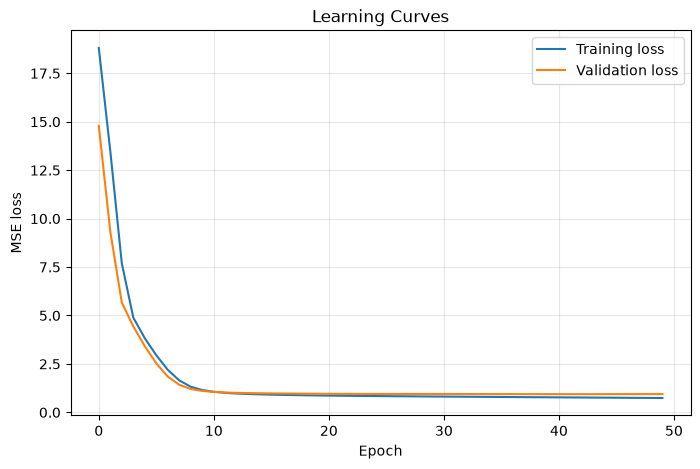

In [7]:
def plot_learning_curves(history, title="Learning Curves"):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Training loss")
    plt.plot(val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_learning_curves(history)


In [8]:
test_loss, test_mae = seq_model.evaluate(X_test, y_test, verbose=0)

print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Test MSE: 1.0470
Test MAE: 0.8110


## 5. Predictions

A regression model outputs a continuous number rather than a class probability.

In [9]:
predictions = seq_model.predict(X_test[:10], verbose=0).ravel()

comparison = np.column_stack([y_test[:10], predictions])

print("Actual      Predicted")
print("----------------------")
for actual, predicted in comparison:
    print(f"{actual:8.3f}    {predicted:8.3f}")


Actual      Predicted
----------------------
   2.333       2.983
  -4.074      -3.061
   4.609       4.503
   0.649       2.501
  -2.158      -3.121
   3.610       4.985
  -5.500      -4.208
   3.044       3.206
   2.628       2.411
   2.616       3.065


# 6. Functional API

The Sequential API is convenient for a simple chain:

```text
Input → Layer → Layer → Layer → Output
```

The Functional API represents a neural network as a computational graph. This lets us create:

- Wide & Deep architectures
- branches
- skip connections
- multiple inputs
- multiple outputs

Basic pattern:

```python
inputs = keras.Input(...)
hidden = layer(inputs)
outputs = layer(hidden)
model = keras.Model(inputs=inputs, outputs=outputs)
```

## 7. Wide & Deep regression model

The Wide & Deep idea combines:

- a **wide/direct path** from the original input
- a **deep path** through hidden layers

Conceptually:

```text
                    ┌────────────── Wide ──────────────┐
                    │                                  │
Input ──────────────┤                                  ├──► Output
                    │                                  │
                    └──► Dense ─► Dense ─► Deep ──────┘
```

The original input is concatenated with the learned deep representation.

In [10]:
inputs = keras.Input(shape=[n_features], name="features")

deep = keras.layers.Dense(30, activation="relu", name="deep_1")(inputs)
deep = keras.layers.Dense(30, activation="relu", name="deep_2")(deep)

wide_and_deep = keras.layers.concatenate(
    [inputs, deep],
    name="wide_and_deep"
)

outputs = keras.layers.Dense(1, name="regression_output")(wide_and_deep)

wide_deep_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="wide_deep_regressor"
)

wide_deep_model.summary()


Model: "wide_deep_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)         │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deep_1 (Dense)                │ (None, 30)                │             270 │ features[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deep_2 (Dense)                │ (None, 30)                │             930 │ deep_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ wide_and_deep (Concatenate)   │ (None, 38)                │               0 │ features[0][0],            │
│                               │                           │                 │ deep_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ regression_output (Dense)     │ (None, 1)                 │              39 │ wide_and_deep[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 19.7327 - mae: 3.4162 - val_loss: 16.0366 - val_mae: 3.1909
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.9560 - mae: 2.9559 - val_loss: 10.9309 - val_mae: 2.5994
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.9832 - mae: 2.2365 - val_loss: 5.7612 - val_mae: 1.7896
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0075 - mae: 1.6135 - val_loss: 4.2645 - val_mae: 1.5174
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9379 - mae: 1.4329 - val_loss: 3.5778 - val_mae: 1.3987
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1511 - mae: 1.2821 - val_loss: 2.8137 - val_mae: 1.2488
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4152 - mae: 1.1272 - val_loss: 2.1314 - val_mae: 1.1039
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8237 - mae: 0.9914 - val_loss: 1.6427 - val_mae: 0.9840
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4305 - 

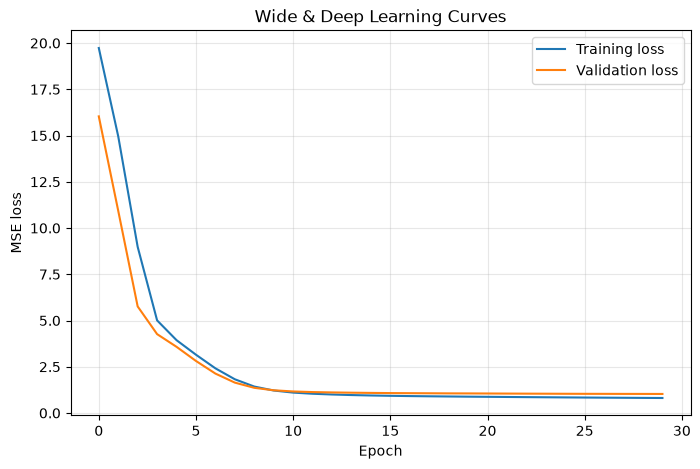

In [11]:
wide_deep_model.compile(
    loss="mse",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["mae"]
)

wide_deep_history = wide_deep_model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    verbose=1
)

plot_learning_curves(
    wide_deep_history,
    title="Wide & Deep Learning Curves"
)


## 8. Multiple inputs

Functional API can accept separate input tensors.

Here we split the 8 features into two groups:

- Input A: first 4 features
- Input B: last 4 features

Each input gets its own small processing branch before the branches are concatenated.

In [12]:
X_A_train = X_train[:, :4]
X_B_train = X_train[:, 4:]

X_A_valid = X_valid[:, :4]
X_B_valid = X_valid[:, 4:]

X_A_test = X_test[:, :4]
X_B_test = X_test[:, 4:]

input_A = keras.Input(shape=[4], name="input_A")
input_B = keras.Input(shape=[4], name="input_B")

branch_A = keras.layers.Dense(16, activation="relu", name="branch_A")(input_A)
branch_B = keras.layers.Dense(16, activation="relu", name="branch_B")(input_B)

merged = keras.layers.concatenate([branch_A, branch_B], name="merge")

hidden = keras.layers.Dense(20, activation="relu", name="combined_hidden")(merged)
output = keras.layers.Dense(1, name="prediction")(hidden)

multi_input_model = keras.Model(
    inputs=[input_A, input_B],
    outputs=output,
    name="multi_input_regressor"
)

multi_input_model.summary()


Model: "multi_input_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_A (InputLayer)          │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_B (InputLayer)          │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ branch_A (Dense)              │ (None, 16)                │              80 │ input_A[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ branch_B (Dense)              │ (None, 16)                │              80 │ input_B[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ merge (Concatenate)           │ (None, 32)                │               0 │ branch_A[0][0],            │
│                               │                           │                 │ branch_B[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ combined_hidden (Dense)       │ (None, 20)                │             660 │ merge[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ prediction (Dense)            │ (None, 1)                 │              21 │ combined_hidden[0][0]      │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
multi_input_model.compile(
    loss="mse",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["mae"]
)

multi_input_history = multi_input_model.fit(
    [X_A_train, X_B_train],
    y_train,
    epochs=30,
    validation_data=([X_A_valid, X_B_valid], y_valid),
    verbose=1
)

multi_input_model.evaluate(
    [X_A_test, X_B_test],
    y_test,
    verbose=0
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 18.7627 - mae: 3.3518 - val_loss: 15.4982 - val_mae: 3.1393
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.8210 - mae: 2.8624 - val_loss: 11.0297 - val_mae: 2.5900
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.8409 - mae: 2.2625 - val_loss: 6.9400 - val_mae: 1.9537
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.5421 - mae: 1.7446 - val_loss: 4.9910 - val_mae: 1.6209
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.3319 - mae: 1.5187 - val_loss: 4.0270 - val_mae: 1.4741
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6161 - mae: 1.3889 - val_loss: 3.2807 - val_mae: 1.3361
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0022 - mae: 1.2710 - val_loss: 2.6774 - val_mae: 1.2162
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5036 - mae: 1.1683 - val_loss: 2.2350 - val_mae: 1.1204
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1373 - 

[1.2977551221847534, 0.8982923626899719]

## 9. Multiple outputs

The Functional API can produce several outputs from one network.

Example:

```text
                    ┌──► price prediction
Input → shared body ┤
                    └──► auxiliary prediction
```

This is useful for **multi-task learning**, where one model learns related tasks together.

In [14]:
inputs = keras.Input(shape=[n_features], name="features")

shared = keras.layers.Dense(32, activation="relu", name="shared_1")(inputs)
shared = keras.layers.Dense(16, activation="relu", name="shared_2")(shared)

price_output = keras.layers.Dense(
    1, name="price"
)(shared)

aux_output = keras.layers.Dense(
    1, name="auxiliary"
)(shared)

multi_output_model = keras.Model(
    inputs=inputs,
    outputs=[price_output, aux_output],
    name="multi_output_regressor"
)

multi_output_model.summary()


Model: "multi_output_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)         │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_1 (Dense)              │ (None, 32)                │             288 │ features[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_2 (Dense)              │ (None, 16)                │             528 │ shared_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ price (Dense)                 │ (None, 1)                 │              17 │ shared_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ auxiliary (Dense)             │ (None, 1)                 │              17 │ shared_2[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 850 (3.32 KB)

 Trainable params: 850 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Create a second continuous target for demonstration.
# It is intentionally related to the same features.
aux_train = (
    1.5 * X_train[:, 0]
    + 0.8 * X_train[:, 1]
    + 0.5 * X_train[:, 2]
)

aux_valid = (
    1.5 * X_valid[:, 0]
    + 0.8 * X_valid[:, 1]
    + 0.5 * X_valid[:, 2]
)

aux_test = (
    1.5 * X_test[:, 0]
    + 0.8 * X_test[:, 1]
    + 0.5 * X_test[:, 2]
)

multi_output_model.compile(
    loss={
        "price": "mse",
        "auxiliary": "mse"
    },
    loss_weights={
        "price": 1.0,
        "auxiliary": 0.3
    },
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics={
        "price": ["mae"],
        "auxiliary": ["mae"]
    }
)

multi_output_history = multi_output_model.fit(
    X_train,
    {"price": y_train, "auxiliary": aux_train},
    validation_data=(
        X_valid,
        {"price": y_valid, "auxiliary": aux_valid}
    ),
    epochs=30,
    verbose=1
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - auxiliary_loss: 3.4947 - auxiliary_mae: 1.4785 - loss: 17.8820 - price_loss: 16.8336 - price_mae: 3.1929 - val_auxiliary_loss: 2.8559 - val_auxiliary_mae: 1.3573 - val_loss: 13.8980 - val_price_loss: 13.1897 - val_price_mae: 2.8593
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auxiliary_loss: 2.6719 - auxiliary_mae: 1.2923 - loss: 12.6494 - price_loss: 11.8478 - price_mae: 2.6627 - val_auxiliary_loss: 2.1020 - val_auxiliary_mae: 1.1659 - val_loss: 9.1164 - val_price_loss: 8.5967 - val_price_mae: 2.2688
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auxiliary_loss: 1.8673 - auxiliary_mae: 1.0759 - loss: 7.7799 - price_loss: 7.2197 - price_mae: 2.0345 - val_auxiliary_loss: 1.3931 - val_auxiliary_mae: 0.9494 - val_loss: 5.7087 - val_price_loss: 5.3763 - val_price_mae: 1.7763
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auxiliary_loss: 1.1806 - auxiliary_mae: 0.8503 - loss: 5.0475 - price_loss: 4.6934 - price_mae: 1.605

## 10. Inspect the computational graph

The Functional API makes the model graph explicit.

Useful tools:

```python
model.summary()
keras.utils.plot_model(...)
```

If Graphviz/Pydot is available, the following creates a visual diagram.

In [16]:
try:
    keras.utils.plot_model(
        wide_deep_model,
        show_shapes=True,
        show_layer_names=True,
        to_file="day46_wide_deep_model.png"
    )
    print("Saved: day46_wide_deep_model.png")
except Exception as e:
    print("Model diagram could not be generated.")
    print("Install pydot/Graphviz if you want the diagram.")
    print(type(e).__name__, e)


You must install pydot (`pip install pydot`) for `plot_model` to work.
Saved: day46_wide_deep_model.png


# 11. Sequential vs Functional API

| Feature | Sequential | Functional |
|---|---|---|
| Simple layer chain | ✅ | ✅ |
| Branches | ❌ | ✅ |
| Multiple inputs | ❌ | ✅ |
| Multiple outputs | ❌ | ✅ |
| Wide & Deep | Limited | ✅ |
| Skip connections | ❌ | ✅ |
| Easy to learn | ✅ | Slightly more complex |
| Computational graph control | Limited | High |

### Mental model

```text
Sequential:
Input → A → B → C → Output

Functional:
             ┌── B ──┐
Input ── A ──┤       ├── Output
             └── C ──┘
```


Quick Revision

**Regression MLP**
```text
Features → Dense(ReLU) → Dense(ReLU) → Dense(1)
```

**Validation**
```text
Training data → update weights
Validation data → monitor generalization
```

**Functional API**
```python
inputs = keras.Input(...)
x = layer(inputs)
outputs = layer(x)
model = keras.Model(inputs, outputs)
```

**Wide & Deep**
```text
Original input ───────────────┐
                              ├──► output
Original input → deep layers ┘
```

**Multiple inputs**
```text
Input A ─┐
         ├──► merge ─► output
Input B ─┘
```

**Multiple outputs**
```text
             ┌──► output A
shared body ─┤
             └──► output B
```

### Takeaway

> **Sequential API is ideal for a straight pipeline. Functional API lets you design the network as a graph.This distinction becomes increasingly important when studying more advanced neural-network architectures.**


